# Here we will first chunk the documents using recursive charcter splitter as it is best and then try retriver actions

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
from prompt_toolkit import document
import json
from langchain_core.documents import Document
with open("data/wikidocs.json", "r", encoding="utf-8") as f:
    data = json.load(f)

documents = "\n\n".join(
    f"Title: {item['title']}\n\nContent: {item['content']}"
    for item in data
)
print(documents)

Title: Artificial intelligence

Content: Artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making. It is a field of research in engineering, mathematics and computer science that develops and studies methods and software that enable machines to perceive their environment and use learning and intelligence to take actions that maximize their chances of achieving defined goals.
High-profile applications of AI include advanced web search engines, chatbots, virtual assistants, autonomous vehicles, and play and analysis in strategy games (e.g., chess and Go). Since the 2020s, generative AI has become widely available to generate images, audio, and videos from text prompts.
The traditional goals of AI research include learning, reasoning, knowledge representation, planning, natural language processing, and perception, as well as support fo

In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

Text_splitter = RecursiveCharacterTextSplitter(chunk_size =500,chunk_overlap =100,separators=["\n\n",'\n'," ","."])

In [4]:

Final_chunk_list = []

# Loop through the list of dictionaries, not the joined string
for doc in data:  
    chunks = Text_splitter.split_text(doc["content"])

    # storing chunks with metadata
    for chunk in chunks:
        Final_chunk_list.append({"title": doc["title"], "content": chunk})

# Total_chunks
print(f"Total no of chunks is :{len(Final_chunk_list)}")
print(Final_chunk_list[0])


Total no of chunks is :475
{'title': 'Artificial intelligence', 'content': 'Artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making. It is a field of research in engineering, mathematics and computer science that develops and studies methods and software that enable machines to perceive their environment and use learning and intelligence to take actions that maximize their chances of achieving defined goals.'}


# checking the spread of the chunks

# chunk distribution





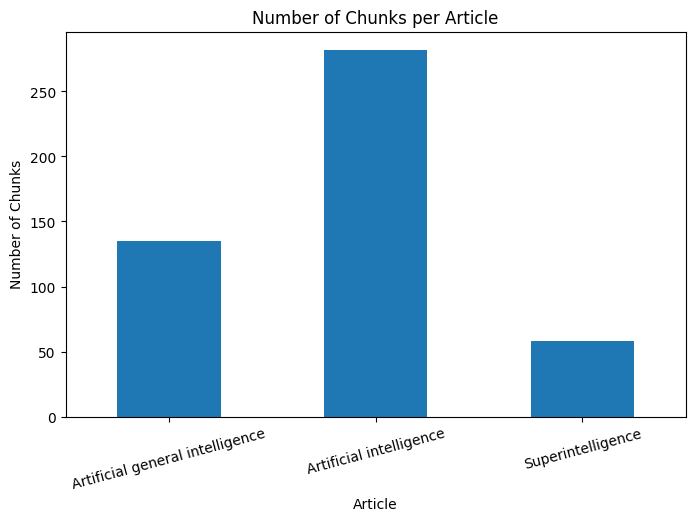

In [5]:
import pandas as pd

import matplotlib.pyplot as plt 
df = pd.DataFrame(Final_chunk_list)

df["Chunk_length"] = df["content"].apply(len)

# 1. Chunks per article
# -----------------------------

chunk_counts = df.groupby("title").size()

plt.figure(figsize=(8,5))
chunk_counts.plot(kind="bar")

plt.title("Number of Chunks per Article")
plt.xlabel("Article")
plt.ylabel("Number of Chunks")

plt.xticks(rotation=15)

plt.show()


# Mr retreriver wouyld be based on bm25 ,hybrid search, MMR ,Reranking

In [6]:
from sentence_transformers import SentenceTransformer
import numpy as np  

#load embedding model

embedding_model = SentenceTransformer(
    "BAAI/bge-base-en-v1.5",
    device="cuda"  )



In [7]:
#extract_chunbk _text


texts = [
    chunk["content"] for chunk in Final_chunk_list
]

#generate embeddings

embeddings = embedding_model.encode(texts,batch_size=32,show_progress_bar=True,convert_to_numpy=True,normalize_embeddings=True)



#verify
print(f"Embeddings Shape:{embeddings.shape}")
print(f"Embedding Dimension :{embeddings.shape[1]}")

Batches: 100%|██████████| 15/15 [00:01<00:00, 14.58it/s]

Embeddings Shape:(475, 768)
Embedding Dimension :768


# now i am preparing a friendly evaluation sructure

In [8]:
embedded_chunks = []

for idx ,(chunk, embedding) in enumerate(zip(Final_chunk_list, embeddings)):

    embedded_chunks.append(
        {
            "chunk_id":idx,
            "title":chunk['title'],
            "content":chunk["content"],
            "embedding":embedding
        }
    )


    #print(f"Embedded chubks :{len(embedded_chunks)}")

print(embedded_chunks[0]["title"])
print(embedded_chunks[0]["embedding"].shape)


Artificial intelligence
(768,)


# now we go for FAISS index creation while preserving metadata for bm25 , hybrid retrival ,MMR rereanking and evaluation

In [9]:
import faiss
import pickle

# creating the faiss index
dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)


index.add(embeddings.astype("float32"))

#savibng faiss index
faiss.write_index(index,"wiki_base.faiss")

# saviing the metadata
with open("embedded_chunks.pkl","wb") as f:
    pickle.dump(embedded_chunks,f)

print(f"Vectors stored in FAISS: {index.ntotal}")
print("FAISS index saved: wiki_bge_base.faiss")
print("Metadata saved: embedded_chunks.pkl")



Vectors stored in FAISS: 475
FAISS index saved: wiki_bge_base.faiss
Metadata saved: embedded_chunks.pkl


# creating the BM25 chunks

In [10]:
from rank_bm25 import BM25Okapi

# Extract text from chunks
corpus = [
    chunk["content"]
    for chunk in embedded_chunks
]

# Tokenize
tokenized_corpus = [
    doc.lower().split()
    for doc in corpus
]

# Create BM25 Index
bm25 = BM25Okapi(tokenized_corpus)

print(f"BM25 indexed {len(tokenized_corpus)} chunks")

BM25 indexed 475 chunks


In [11]:
#saving the tokenized corpus

import pickle

with open("tokenized_corpus.pkl", "wb") as f:
    pickle.dump(tokenized_corpus, f)

print("Tokenized corpus saved successfully")

Tokenized corpus saved successfully


# Save BM25 Object (Optional)

In [12]:
with open("bm25.pkl", "wb") as f:
    pickle.dump(bm25, f)

print("BM25 object saved")

BM25 object saved


# Retrieval Assets So Far

1) wiki_bge_base.faiss      ← FAISS Vector DB
2) embedded_chunks.pkl      ← Metadata
3) tokenized_corpus.pkl     ← BM25 corpus
4) bm25.pkl                 ← BM25 index (optional)

In [16]:
from faiss_ret import faiss_retrieve
# testing retriver




query = "Who coined superintelligence?"

results = faiss_retrieve(
    query=query,
    k=5
)

results

[{'rank': 1,
  'chunk_id': 270,
  'title': 'Artificial intelligence',
  'score': 0.7298871278762817,
  'content': '=== Superintelligence and the singularity ===\nA superintelligence is a hypothetical agent that would possess intelligence far surpassing that of the brightest and most gifted human mind. If research into artificial general intelligence produced sufficiently intelligent software, it might be able to reprogram and improve itself. The improved software would be even better at improving itself, leading to what I. J. Good called an "intelligence explosion" and Vernor Vinge called a "singularity".'},
 {'rank': 2,
  'chunk_id': 417,
  'title': 'Superintelligence',
  'score': 0.7178353071212769,
  'content': 'A superintelligence is a hypothetical agent that possesses intelligence surpassing that of the most gifted human minds. Philosopher Nick Bostrom defines superintelligence as "any intellect that greatly exceeds the cognitive performance of humans in virtually all domains of i

In [17]:
results =faiss_retrieve(
    "What are the risks of AGI?",
    k=20
)

for r in results:
    print(r["title"])

Artificial general intelligence
Artificial general intelligence
Superintelligence
Artificial general intelligence
Artificial general intelligence
Artificial general intelligence
Artificial general intelligence
Superintelligence
Artificial general intelligence
Artificial general intelligence
Artificial general intelligence
Artificial general intelligence
Superintelligence
Artificial intelligence
Superintelligence
Artificial general intelligence
Artificial general intelligence
Artificial general intelligence
Artificial general intelligence
Artificial general intelligence


In [18]:
from bm25_ret import bm25_retrieve

query = "Who coined superintelligence?"

results = bm25_retrieve(
    query=query,
    k=5
)

results

[{'rank': 1,
  'chunk_id': 190,
  'title': 'Artificial intelligence',
  'score': 8.146262136509263,
  'content': 'Friendly AI are machines that have been designed from the beginning to minimize risks and to make choices that benefit humans. Eliezer Yudkowsky, who coined the term, argues that developing friendly AI should be a higher research priority: it may require a large investment and it must be completed before AI becomes an existential risk.'},
 {'rank': 2,
  'chunk_id': 405,
  'title': 'Artificial general intelligence',
  'score': 7.423114962879744,
  'content': 'Many scholars who are concerned about existential risk advocate for more research into solving the "control problem" to answer the question: what types of safeguards, algorithms, or architectures can programmers implement to maximise the probability that their recursively-improving AI would continue to behave in a friendly, rather than destructive, manner after it reaches superintelligence? Solving the control problem i

# testing the hybrid(rrf)

In [20]:
from hybrid_ret import rrf_fusion

query = "Who coined superintelligence?"

results = rrf_fusion(
    query=query
)

results[:5]

[{'chunk_id': 427,
  'title': 'Superintelligence',
  'content': 'light". Thus, the simplest example of a superintelligence may be an emulated human mind running on much faster hardware than the brain. A human-like reasoner who could think millions of times faster than current humans would have a dominant advantage in most reasoning tasks, particularly ones that require haste or long strings of actions.',
  'rrf_score': 0.028850145288501453},
 {'chunk_id': 458,
  'title': 'Superintelligence',
  'content': 'When we create the first superintelligent entity, we might make a mistake and give it goals that lead it to annihilate humankind, assuming its enormous intellectual advantage gives it the power to do so. For example, we could mistakenly elevate a subgoal to the status of a supergoal. We tell it to solve a mathematical problem, and it complies by turning all the matter in the solar system into a giant calculating device, in the process killing the person who asked the question.',
  'rr

# now lets rerank them

In [21]:
from hybrid_ret import rrf_fusion
from reranker import rerank_results

query = "Who coined superintelligence?"

rrf_results = rrf_fusion(
    query=query,
    faiss_k=20,
    bm25_k=20
)

final_results = rerank_results(
    query=query,
    candidates=rrf_results,
    top_k=5
)

for rank, result in enumerate(final_results, start=1):

    print("=" * 100)

    print(f"Rank: {rank}")
    print(f"Rerank Score: {result['rerank_score']:.4f}")
    print(f"Title: {result['title']}")

    print()
    print(result["content"][:500])
    print()

Rank: 1
Rerank Score: 0.9833
Title: Artificial intelligence

The field of AI research was founded at a workshop at Dartmouth College in 1956. The first AI program, Logic Theorist, was presented at the workshop, created by future Turing Award winner Allen Newell and future Nobel Laureate Herbert A. Simon, in collaboration with J. C. Shaw. Many of the workshop attendees became the leaders of AI research in the 1960s. They and their students produced programs that the press described as "astonishing": computers were learning checkers strategies, solving

Rank: 2
Rerank Score: 0.2899
Title: Artificial intelligence

The opinions amongst experts and industry insiders are mixed, with sizable fractions both concerned and unconcerned by risk from eventual superintelligent AI. Personalities such as Stephen Hawking, Bill Gates, and Elon Musk, as well as AI pioneers such as Geoffrey Hinton, Yoshua Bengio, Stuart Russell, Demis Hassabis, and Sam Altman, have expressed concerns about existential ris